# Week 4: Hyperparameter Experimentation

The baseline CNN developed in Week 2 is used as the starting point for this
experiment. In Week 4, selected hyperparameters are adjusted to observe how
they affect classification performance. The experiments focus on learning
rate, dropout rate, and the number of neurons in the dense layer.

The same subject-level training, validation, and testing partitions are
maintained throughout the experiments to ensure a consistent comparison.

In [59]:
# CNN model function for hyperparameter experimentation

def create_experiment_model(
    learning_rate=0.001,
    dropout_rate=0.5,
    dense_units=128
):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 1)),

        # Data augmentation
        data_augmentation,

        # Convolutional layers
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Fully connected layer
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(dense_units, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),

        # Binary classification
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Experiment 1: Effect of Learning Rate

The baseline model uses a learning rate of 0.001. In this experiment, the
learning rate is reduced to 0.0001 while keeping the other hyperparameters
unchanged. The purpose is to observe whether a smaller learning rate affects
the model's ability to learn and generalize.

In [60]:
# Experiment 1: Reduced learning rate

experiment_1_model = create_experiment_model(
    learning_rate=0.0001,
    dropout_rate=0.5,
    dense_units=128
)

experiment_1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Train Experiment 1

early_stopping_exp1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

experiment_1_history = experiment_1_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_exp1],
    verbose=1
)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7024 - loss: 0.6183 - val_accuracy: 0.7924 - val_loss: 0.6586
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8458 - loss: 0.3426 - val_accuracy: 0.5339 - val_loss: 0.7281
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8773 - loss: 0.2449 - val_accuracy: 0.6356 - val_loss: 0.4991
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9229 - loss: 0.1786 - val_accuracy: 0.7924 - val_loss: 0.3980
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9445 - loss: 0.1358 - val_accuracy: 0.8856 - val_loss: 0.3049
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9624 - loss: 0.1074 - val_accuracy: 0.8602 - val_loss: 0.2985
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9793 - loss: 0.0694 - val_accuracy: 0.9068 - val_loss: 0.1890
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9784 - loss: 0.0575 - val_accuracy: 0.9110 - v

In [62]:
# Evaluate Experiment 1

experiment_1_prob = experiment_1_model.predict(X_test)

experiment_1_pred = (
    experiment_1_prob >= 0.5
).astype(int).flatten()

exp1_accuracy = accuracy_score(y_test, experiment_1_pred)
exp1_precision = precision_score(y_test, experiment_1_pred)
exp1_recall = recall_score(y_test, experiment_1_pred)
exp1_f1 = f1_score(y_test, experiment_1_pred)

print("Experiment 1 Results")
print("--------------------")
print(f"Accuracy : {exp1_accuracy:.4f}")
print(f"Precision: {exp1_precision:.4f}")
print(f"Recall   : {exp1_recall:.4f}")
print(f"F1-Score : {exp1_f1:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Experiment 1 Results
--------------------
Accuracy : 0.9762
Precision: 0.9971
Recall   : 0.9659
F1-Score : 0.9812


## Experiment 2: Effect of Dropout Rate

In this experiment, the dropout rate is reduced from the baseline value of 0.5 to 0.3 while keeping the learning rate and dense-layer configuration unchanged. The purpose is to observe how changing dropout affects the CNN's classification performance.

In [63]:
# Experiment 2: Reduced dropout rate

experiment_2_model = create_experiment_model(
    learning_rate=0.001,
    dropout_rate=0.3,
    dense_units=128
)

experiment_2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Train Experiment 2

early_stopping_exp2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

experiment_2_history = experiment_2_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_exp2],
    verbose=1
)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8430 - loss: 0.3212 - val_accuracy: 0.8814 - val_loss: 0.2903
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9704 - loss: 0.0894 - val_accuracy: 0.9576 - val_loss: 0.1474
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9788 - val_loss: 0.0595
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9901 - loss: 0.0272 - val_accuracy: 0.9280 - val_loss: 0.1404
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9920 - loss: 0.0169 - val_accuracy: 0.9958 - val_loss: 0.0260
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9962 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9703 - val_loss: 0.0741
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9962 - loss: 0.0083 - val_accuracy: 0.9068 - va

In [65]:
# Evaluate Experiment 2

experiment_2_prob = experiment_2_model.predict(X_test)

experiment_2_pred = (
    experiment_2_prob >= 0.5
).astype(int).flatten()

exp2_accuracy = accuracy_score(y_test, experiment_2_pred)
exp2_precision = precision_score(y_test, experiment_2_pred)
exp2_recall = recall_score(y_test, experiment_2_pred)
exp2_f1 = f1_score(y_test, experiment_2_pred)

print("Experiment 2 Results")
print("--------------------")
print(f"Accuracy : {exp2_accuracy:.4f}")
print(f"Precision: {exp2_precision:.4f}")
print(f"Recall   : {exp2_recall:.4f}")
print(f"F1-Score : {exp2_f1:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Experiment 2 Results
--------------------
Accuracy : 0.9768
Precision: 0.9971
Recall   : 0.9669
F1-Score : 0.9817


In [66]:
# Experiment 3: Increased dense layer size

experiment_3_model = create_experiment_model(
    learning_rate=0.001,
    dropout_rate=0.5,
    dense_units=256
)

In [67]:
# Train Experiment 3

early_stopping_exp3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

experiment_3_history = experiment_3_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_exp3],
    verbose=1
)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8256 - loss: 0.3429 - val_accuracy: 0.8814 - val_loss: 0.3181
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9652 - loss: 0.0940 - val_accuracy: 0.9958 - val_loss: 0.0955
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9798 - loss: 0.0547 - val_accuracy: 0.9576 - val_loss: 0.1055
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9911 - loss: 0.0330 - val_accuracy: 0.9915 - val_loss: 0.0434
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9958 - val_loss: 0.0257
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 0.9449 - val_loss: 0.0925
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9873 - val_loss: 0.0439
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9322 - v

In [68]:
# Evaluate Experiment 3

experiment_3_prob = experiment_3_model.predict(X_test)

experiment_3_pred = (
    experiment_3_prob >= 0.5
).astype(int).flatten()

exp3_accuracy = accuracy_score(y_test, experiment_3_pred)
exp3_precision = precision_score(y_test, experiment_3_pred)
exp3_recall = recall_score(y_test, experiment_3_pred)
exp3_f1 = f1_score(y_test, experiment_3_pred)

print("Experiment 3 Results")
print("--------------------")
print(f"Accuracy : {exp3_accuracy:.4f}")
print(f"Precision: {exp3_precision:.4f}")
print(f"Recall   : {exp3_recall:.4f}")
print(f"F1-Score : {exp3_f1:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Experiment 3 Results
--------------------
Accuracy : 0.9792
Precision: 0.9971
Recall   : 0.9706
F1-Score : 0.9837


## Comparison of Hyperparameter Experiments

The three experiments were compared to determine how changes in the learning rate, dropout rate, and dense-layer size affected the CNN's classification performance. Accuracy, precision, recall, and F1-score were used for comparison.

In [75]:
# Week 4 Experiment Comparison

experiment_results_display = pd.DataFrame({
    "Model": [
        "Week 2 Baseline",
        "Experiment 1 - Learning Rate",
        "Experiment 2 - Dropout",
        "Experiment 3 - Dense Units"
    ],
    "Accuracy": [
        "95.17%",
        "97.62%",
        "97.68%",
        "97.92%"
    ],
    "Precision": [
        "99.69%",
        "99.71%",
        "99.71%",
        "99.71%"
    ],
    "Recall": [
        "92.80%",
        "96.59%",
        "96.69%",
        "97.06%"
    ],
    "F1-Score": [
        "96.13%",
        "98.12%",
        "98.17%",
        "98.37%"
    ]
})
display(experiment_results_display)

,Model,Accuracy,Precision,Recall,F1-Score
0,Week 2 Baseline,95.17%,99.69%,92.80%,96.13%
1,Experiment 1 - Learning Rate,97.62%,99.71%,96.59%,98.12%
2,Experiment 2 - Dropout,97.68%,99.71%,96.69%,98.17%
3,Experiment 3 - Dense Units,97.92%,99.71%,97.06%,98.37%


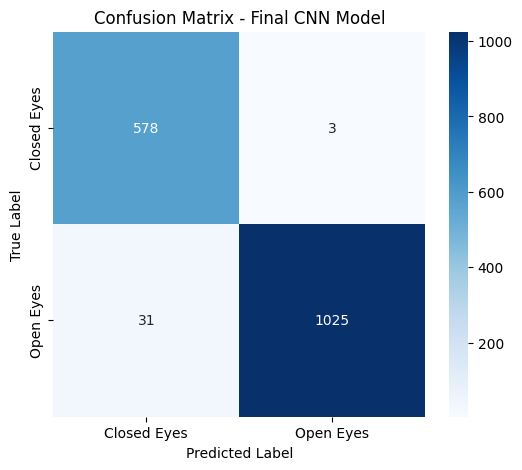

In [76]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Use Experiment 3 as the final model
final_predictions = experiment_3_pred

# Confusion matrix
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Closed Eyes", "Open Eyes"],
    yticklabels=["Closed Eyes", "Open Eyes"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final CNN Model")
plt.show()

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)

print(f"Final Accuracy:  {final_accuracy * 100:.2f}%")
print(f"Final Precision: {final_precision * 100:.2f}%")
print(f"Final Recall:    {final_recall * 100:.2f}%")
print(f"Final F1-Score:  {final_f1 * 100:.2f}%")

Final Accuracy:  97.92%
Final Precision: 99.71%
Final Recall:    97.06%
Final F1-Score:  98.37%


In [78]:
print("Final Classification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Closed Eyes", "Open Eyes"]
    )
)

Final Classification Report:

              precision    recall  f1-score   support

 Closed Eyes       0.95      0.99      0.97       581
   Open Eyes       1.00      0.97      0.98      1056

    accuracy                           0.98      1637
   macro avg       0.97      0.98      0.98      1637
weighted avg       0.98      0.98      0.98      1637

